In [1]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

In [ ]:
# 가입자 중 몇 명이 친구 5명을 확보했는가?
q1_unlock_sql = """
WITH eligible_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 탈퇴한 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
)

SELECT
  COUNT(*) AS total_user_count,

  COUNTIF(
    service_unlocked_at IS NOT NULL
  ) AS unlocked_user_count,

  COUNTIF(
    service_unlocked_at IS NULL
  ) AS not_unlocked_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(service_unlocked_at IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS unlock_rate_percent

FROM eligible_users
"""

In [5]:
cost(q1_unlock_sql)

예상 스캔량: 0.457 MiB
예상 스캔량: 0.000446 GiB
월 1 TiB 무료 용량의 약 0.00004355%


0.00044596102088689804

In [6]:
df_q1 = bq.query(q1_unlock_sql).to_dataframe()
df_q1

,total_user_count,unlocked_user_count,not_unlocked_user_count,unlock_rate_percent
0,18001,16673,1328,92.62


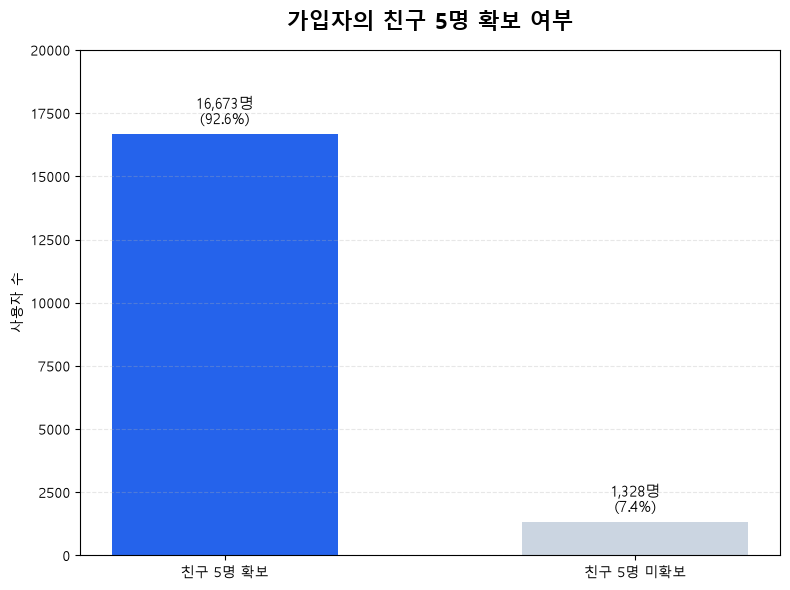

In [7]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

q1 = df_q1.iloc[0]

labels = [
    "친구 5명 확보",
    "친구 5명 미확보"
]

values = [
    q1["unlocked_user_count"],
    q1["not_unlocked_user_count"]
]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels,
    values,
    color=["#2563EB", "#CBD5E1"],
    width=0.55
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"({value / q1['total_user_count'] * 100:.1f}%)"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "가입자의 친구 5명 확보 여부",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("사용자 수")
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# 친구 5명을 확보하기까지 평균 며칠이 걸리는가?
q2_unlock_days_sql = """
WITH unlocked_users AS (
  SELECT
    u.id AS user_id,

    TIMESTAMP_DIFF(
      u.service_unlocked_at,
      u.created_at,
      SECOND
    ) / 86400.0 AS unlock_days

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    -- 탈퇴한 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
)

SELECT
  COUNT(*) AS unlocked_user_count,

  ROUND(
    AVG(unlock_days),
    2
  ) AS avg_unlock_days,

  ROUND(
    APPROX_QUANTILES(
      unlock_days,
      100
    )[OFFSET(50)],
    2
  ) AS median_unlock_days,

  ROUND(
    MIN(unlock_days),
    2
  ) AS min_unlock_days,

  ROUND(
    MAX(unlock_days),
    2
  ) AS max_unlock_days

FROM unlocked_users
"""

In [9]:
cost(q2_unlock_days_sql)

예상 스캔량: 0.609 MiB
예상 스캔량: 0.000595 GiB
월 1 TiB 무료 용량의 약 0.00005812%


0.0005951439961791039

In [10]:
df_q2 = bq.query(q2_unlock_days_sql).to_dataframe()
df_q2

,unlocked_user_count,avg_unlock_days,median_unlock_days,min_unlock_days,max_unlock_days
0,16673,1.53,1.54,0.04,3.0


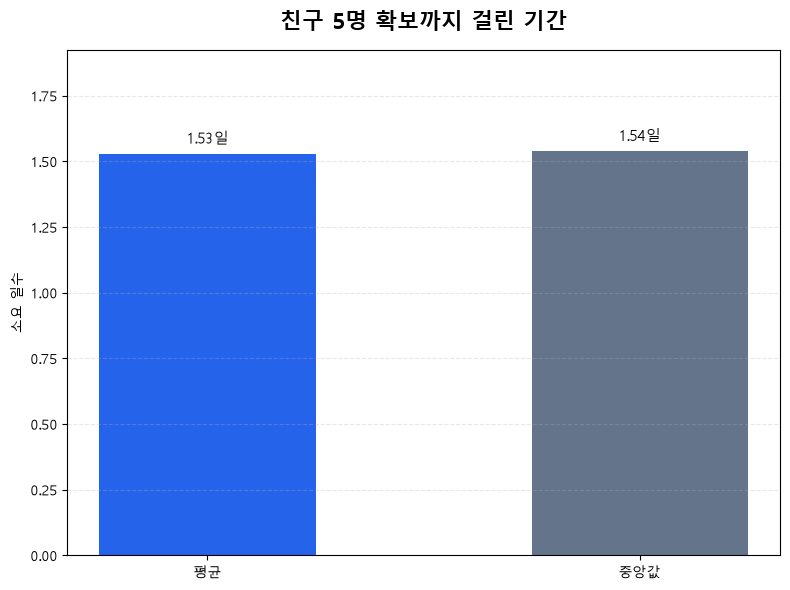

In [11]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

q2 = df_q2.iloc[0]

labels = [
    "평균",
    "중앙값"
]

values = [
    q2["avg_unlock_days"],
    q2["median_unlock_days"]
]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels,
    values,
    color=["#2563EB", "#64748B"],
    width=0.5
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}일"
        for value in values
    ],
    padding=5,
    fontsize=11
)

ax.set_title(
    "친구 5명 확보까지 걸린 기간",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("소요 일수")
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# 친구 조건을 충족한 사용자는 실제로 투표를 시작하는가?
q3_vote_start_sql = """
WITH unlocked_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    -- 탈퇴한 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

vote_started_users AS (
  SELECT DISTINCT
    u.user_id

  FROM unlocked_users AS u

  JOIN `ping-v2-503916.raw.vote_session` AS vs
    ON vs._source = 'local'
   AND vs.user_id = u.user_id
   AND vs._deleted_at IS NULL
   AND vs.started_at >= u.service_unlocked_at
)

SELECT
  COUNT(*) AS unlocked_user_count,

  COUNTIF(
    v.user_id IS NOT NULL
  ) AS vote_started_user_count,

  COUNTIF(
    v.user_id IS NULL
  ) AS vote_not_started_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_start_rate_percent

FROM unlocked_users AS u

LEFT JOIN vote_started_users AS v
  ON u.user_id = v.user_id
"""

In [13]:
cost(q3_vote_start_sql)

예상 스캔량: 33.061 MiB
예상 스캔량: 0.032286 GiB
월 1 TiB 무료 용량의 약 0.00315294%


0.03228606376796961

In [14]:
df_q3 = bq.query(q3_vote_start_sql).to_dataframe()
df_q3

,unlocked_user_count,vote_started_user_count,vote_not_started_user_count,vote_start_rate_percent
0,16673,14907,1766,89.41


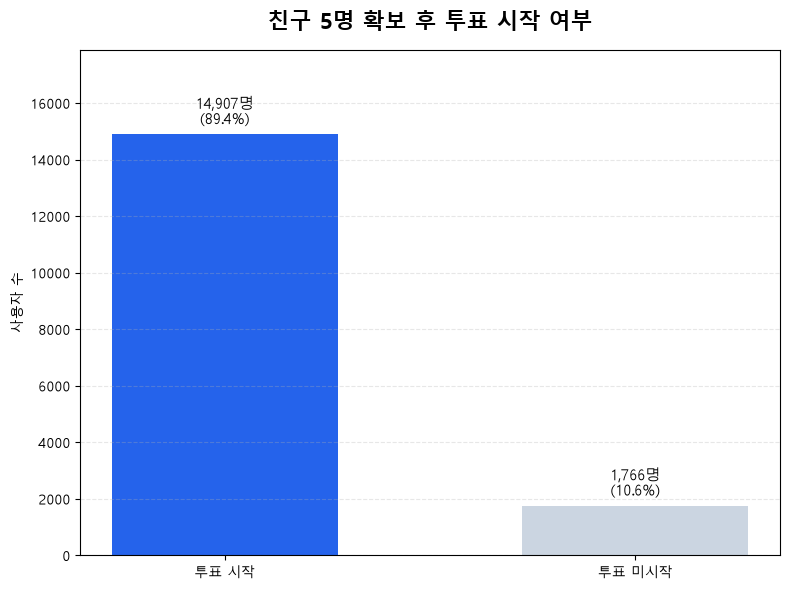

In [15]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

q3 = df_q3.iloc[0]

labels = [
    "투표 시작",
    "투표 미시작"
]

values = [
    q3["vote_started_user_count"],
    q3["vote_not_started_user_count"]
]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels,
    values,
    color=["#2563EB", "#CBD5E1"],
    width=0.55
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"({value / q3['unlocked_user_count'] * 100:.1f}%)"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "친구 5명 확보 후 투표 시작 여부",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("사용자 수")
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# 투표를 시작했지만 완료하지 못한 사용자는 얼마나 되는가?
q4_vote_completion_sql = """
WITH unlocked_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    -- 탈퇴한 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

vote_started_users AS (
  SELECT DISTINCT
    u.user_id

  FROM unlocked_users AS u

  JOIN `ping-v2-503916.raw.vote_session` AS vs
    ON vs._source = 'local'
   AND vs.user_id = u.user_id
   AND vs._deleted_at IS NULL
   AND vs.started_at >= u.service_unlocked_at
),

vote_completed_users AS (
  SELECT DISTINCT
    u.user_id

  FROM unlocked_users AS u

  JOIN `ping-v2-503916.raw.vote_session` AS vs
    ON vs._source = 'local'
   AND vs.user_id = u.user_id
   AND vs._deleted_at IS NULL
   AND vs.started_at >= u.service_unlocked_at
   AND vs.status = 'COMPLETED'
   AND vs.completed_at IS NOT NULL
)

SELECT
  COUNT(*) AS vote_started_user_count,

  COUNTIF(
    c.user_id IS NOT NULL
  ) AS vote_completed_user_count,

  COUNTIF(
    c.user_id IS NULL
  ) AS started_not_completed_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(c.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_completion_rate_percent,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(c.user_id IS NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS started_not_completed_rate_percent

FROM vote_started_users AS s

LEFT JOIN vote_completed_users AS c
  ON s.user_id = c.user_id
"""

In [17]:
cost(q4_vote_completion_sql)

예상 스캔량: 57.775 MiB
예상 스캔량: 0.056420 GiB
월 1 TiB 무료 용량의 약 0.00550981%


0.05642044451087713

In [18]:
df_q4 = bq.query(
    q4_vote_completion_sql
).to_dataframe()

df_q4

,vote_started_user_count,vote_completed_user_count,started_not_completed_user_count,vote_completion_rate_percent,started_not_completed_rate_percent
0,14907,12482,2425,83.73,16.27


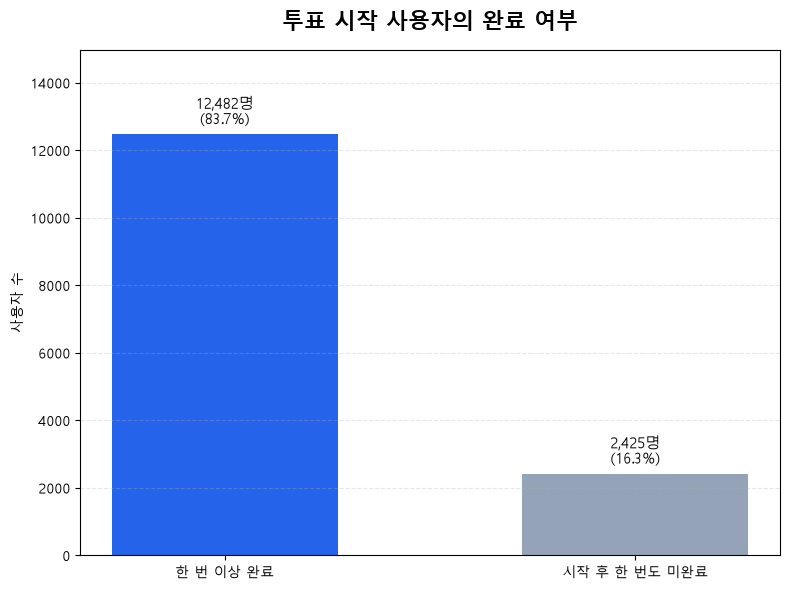

In [19]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

q4 = df_q4.iloc[0]

labels = [
    "한 번 이상 완료",
    "시작 후 한 번도 미완료"
]

values = [
    q4["vote_completed_user_count"],
    q4["started_not_completed_user_count"]
]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels,
    values,
    color=["#2563EB", "#94A3B8"],
    width=0.55
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"({value / q4['vote_started_user_count'] * 100:.1f}%)"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "투표 시작 사용자의 완료 여부",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("사용자 수")
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# 친구 5명 미확보 사용자의 투표 여부
q_locked_vote_sql = """
WITH locked_users AS (
  SELECT
    u.id AS user_id,
    u.friend_count,
    u.created_at AS signup_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 친구 5명 게이트를 통과하지 않은 사용자
    AND u.service_unlocked_at IS NULL

    -- 탈퇴 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

vote_session_users AS (
  -- 투표 세션을 시작한 사용자
  SELECT DISTINCT
    vs.user_id
  FROM `ping-v2-503916.raw.vote_session` AS vs
  WHERE vs._source = 'local'
    AND vs._deleted_at IS NULL
),

actual_vote_users AS (
  -- 후보를 실제로 선택한 사용자
  SELECT DISTINCT
    vi.user_id
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
)

SELECT
  COUNT(*) AS locked_user_count,

  -- 투표 세션은 생성된 사용자
  COUNTIF(
    vs.user_id IS NOT NULL
  ) AS session_started_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(vs.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS session_started_rate_percent,

  -- 실제 후보를 선택한 사용자
  COUNTIF(
    av.user_id IS NOT NULL
  ) AS actual_vote_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(av.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS actual_vote_rate_percent

FROM locked_users AS u

LEFT JOIN vote_session_users AS vs
  ON u.user_id = vs.user_id

LEFT JOIN actual_vote_users AS av
  ON u.user_id = av.user_id
"""

In [21]:
cost(q_locked_vote_sql)

예상 스캔량: 312.842 MiB
예상 스캔량: 0.305509 GiB
월 1 TiB 무료 용량의 약 0.02983489%


0.3055093204602599

In [22]:
df_locked_vote = bq.query(
    q_locked_vote_sql
).to_dataframe()

df_locked_vote

,locked_user_count,session_started_user_count,session_started_rate_percent,actual_vote_user_count,actual_vote_rate_percent
0,1328,0,0.0,0,0.0


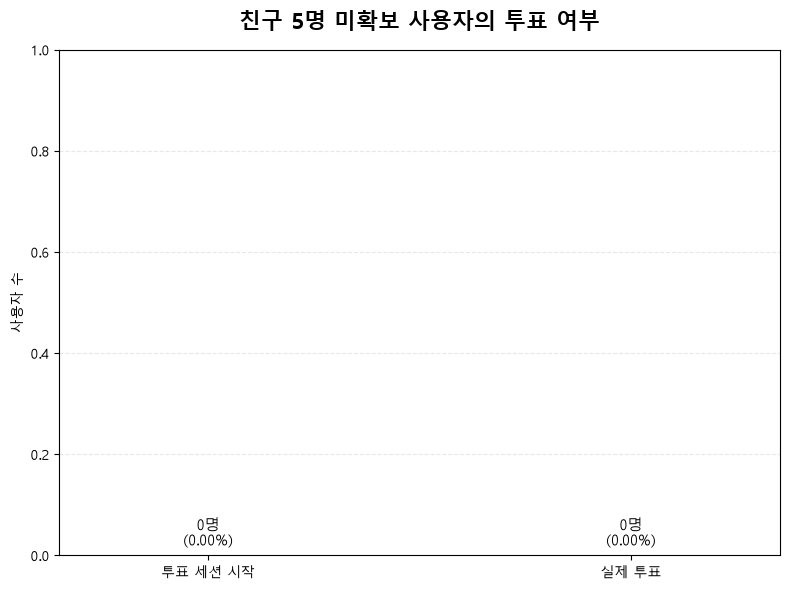

In [23]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

result = df_locked_vote.iloc[0]

labels = [
    "투표 세션 시작",
    "실제 투표"
]

values = [
    result["session_started_user_count"],
    result["actual_vote_user_count"]
]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    labels,
    values,
    color=["#94A3B8", "#DC2626"],
    width=0.55
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"({value / result['locked_user_count'] * 100:.2f}%)"
    if result["locked_user_count"] > 0
    else "0명"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "친구 5명 미확보 사용자의 투표 여부",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("사용자 수")
ax.set_ylim(
    0,
    max(values) * 1.25 if max(values) > 0 else 1
)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# 가입자, 탈퇴자, 현재 비탈퇴 사용자 비교
user_status_comparison_sql = """
WITH synthetic_users AS (
  -- 삭제되지 않은 전체 합성 가입자
  SELECT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
),

withdrawn_users AS (
  -- 유효한 탈퇴 기록이 있는 사용자
  SELECT DISTINCT
    w.user_id
  FROM `ping-v2-503916.raw.user_withdrawal` AS w
  WHERE w._source = 'local'
    AND w._deleted_at IS NULL
)

SELECT
  -- 서비스에 가입한 전체 사용자
  COUNT(*) AS total_signup_user_count,

  -- 탈퇴 기록이 있는 사용자
  COUNTIF(
    w.user_id IS NOT NULL
  ) AS withdrawn_user_count,

  -- 탈퇴 기록이 없는 사용자
  COUNTIF(
    w.user_id IS NULL
  ) AS non_withdrawn_user_count,

  -- 탈퇴율
  ROUND(
    SAFE_DIVIDE(
      COUNTIF(w.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS withdrawal_rate_percent,

  -- 비탈퇴 사용자 비율
  ROUND(
    SAFE_DIVIDE(
      COUNTIF(w.user_id IS NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS non_withdrawal_rate_percent

FROM synthetic_users AS u

LEFT JOIN withdrawn_users AS w
  ON u.user_id = w.user_id
"""

In [25]:
cost(user_status_comparison_sql)

예상 스캔량: 0.315 MiB
예상 스캔량: 0.000308 GiB
월 1 TiB 무료 용량의 약 0.00003005%


0.0003077080473303795

In [26]:
df_user_status = bq.query(
    user_status_comparison_sql
).to_dataframe()

df_user_status

,total_signup_user_count,withdrawn_user_count,non_withdrawn_user_count,withdrawal_rate_percent,non_withdrawal_rate_percent
0,20000,1999,18001,9.99,90.0


In [27]:
vote_cycle_comparison_sql = """
WITH eligible_users AS (
  -- 합성 가입자 중 탈퇴 기록이 없는 사용자
  SELECT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

voted_users AS (
  -- 실제로 후보를 한 번이라도 선택한 사용자
  SELECT DISTINCT
    vi.user_id
  FROM `ping-v2-503916.raw.vote_item` AS vi

  JOIN eligible_users AS u
    ON vi.user_id = u.user_id

  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

completed_vote_sessions AS (
  -- 실제 투표 10개를 모두 완료한 세션
  SELECT
    vs.user_id,
    vs.id AS session_id

  FROM `ping-v2-503916.raw.vote_session` AS vs

  JOIN eligible_users AS u
    ON vs.user_id = u.user_id

  JOIN `ping-v2-503916.raw.vote_item` AS vi
    ON vi._source = vs._source
   AND vi.session_id = vs.id
   AND vi._deleted_at IS NULL

  WHERE vs._source = 'local'
    AND vs._deleted_at IS NULL
    AND vs.status = 'COMPLETED'
    AND vs.completed_at IS NOT NULL
    AND vs.item_count = 10

  GROUP BY
    vs.user_id,
    vs.id

  HAVING COUNT(
    DISTINCT IF(
      vi.voted_at IS NOT NULL,
      vi.id,
      NULL
    )
  ) >= 10
),

completed_cycle_users AS (
  -- 10문항 사이클을 한 번이라도 완료한 사용자
  SELECT DISTINCT
    user_id
  FROM completed_vote_sessions
)

SELECT
  COUNT(*) AS eligible_user_count,

  COUNTIF(
    v.user_id IS NOT NULL
  ) AS voted_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS voted_user_rate_percent,

  COUNTIF(
    c.user_id IS NOT NULL
  ) AS completed_cycle_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(c.user_id IS NOT NULL),
      COUNT(*)
    ) * 100,
    2
  ) AS completed_cycle_rate_percent,

  -- 한 번 이상 투표했지만 10문항은 완료하지 못한 사용자
  COUNTIF(
    v.user_id IS NOT NULL
    AND c.user_id IS NULL
  ) AS voted_not_completed_user_count,

  -- 한 번 이상 투표한 사용자 중 10문항 완료율
  ROUND(
    SAFE_DIVIDE(
      COUNTIF(c.user_id IS NOT NULL),
      COUNTIF(v.user_id IS NOT NULL)
    ) * 100,
    2
  ) AS completion_rate_among_voters_percent

FROM eligible_users AS u

LEFT JOIN voted_users AS v
  ON u.user_id = v.user_id

LEFT JOIN completed_cycle_users AS c
  ON u.user_id = c.user_id
"""

In [28]:
cost(vote_cycle_comparison_sql)

예상 스캔량: 565.253 MiB
예상 스캔량: 0.552005 GiB
월 1 TiB 무료 용량의 약 0.05390676%


0.5520052360370755

In [29]:
df_vote_cycle = bq.query(
    vote_cycle_comparison_sql
).to_dataframe()

df_vote_cycle

,eligible_user_count,voted_user_count,voted_user_rate_percent,completed_cycle_user_count,completed_cycle_rate_percent,voted_not_completed_user_count,completion_rate_among_voters_percent
0,18001,14889,82.71,11025,61.25,3864,74.05


In [30]:
result = df_vote_cycle.iloc[0]

print(
    f"전체 분석 대상: "
    f"{result['eligible_user_count']:,.0f}명"
)

print(
    f"한 번이라도 투표한 사용자: "
    f"{result['voted_user_count']:,.0f}명 "
    f"({result['voted_user_rate_percent']:.2f}%)"
)

print(
    f"10문항 사이클 완료 사용자: "
    f"{result['completed_cycle_user_count']:,.0f}명 "
    f"({result['completed_cycle_rate_percent']:.2f}%)"
)

print(
    f"투표는 했지만 10문항을 완료하지 못한 사용자: "
    f"{result['voted_not_completed_user_count']:,.0f}명"
)

print(
    f"투표 사용자 중 10문항 완료율: "
    f"{result['completion_rate_among_voters_percent']:.2f}%"
)

전체 분석 대상: 18,001명
한 번이라도 투표한 사용자: 14,889명 (82.71%)
10문항 사이클 완료 사용자: 11,025명 (61.25%)
투표는 했지만 10문항을 완료하지 못한 사용자: 3,864명
투표 사용자 중 10문항 완료율: 74.05%


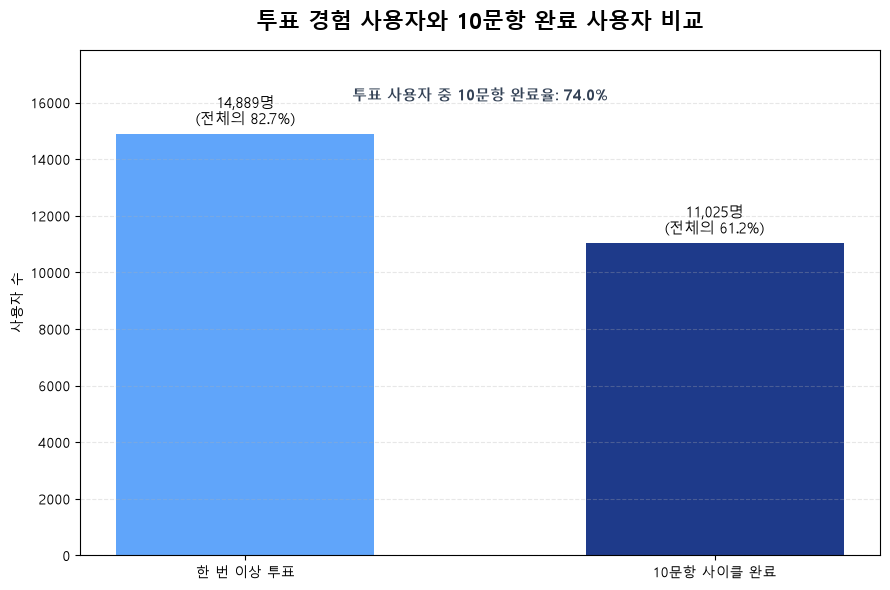

In [31]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

result = df_vote_cycle.iloc[0]

total_count = int(
    result["eligible_user_count"]
)

labels = [
    "한 번 이상 투표",
    "10문항 사이클 완료"
]

values = [
    result["voted_user_count"],
    result["completed_cycle_user_count"]
]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    labels,
    values,
    color=["#60A5FA", "#1E3A8A"],
    width=0.55
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"(전체의 {value / total_count * 100:.1f}%)"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "투표 경험 사용자와 10문항 완료 사용자 비교",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("사용자 수")
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# 투표 사용자 중 완료율 표시
ax.text(
    0.5,
    max(values) * 1.08,
    (
        "투표 사용자 중 10문항 완료율: "
        f"{result['completion_rate_among_voters_percent']:.1f}%"
    ),
    ha="center",
    fontsize=11,
    fontweight="bold",
    color="#334155"
)

plt.tight_layout()
plt.show()

In [ ]:
# 첫 10문항 완료 이후 발생한 힌트 구매만 집계
completed_user_hint_funnel_sql = """
WITH eligible_users AS (
  -- 합성 데이터 중 탈퇴하지 않은 사용자
  SELECT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

completed_sessions AS (
  -- 실제 투표 10개를 모두 완료한 세션
  SELECT
    vs.user_id,
    vs.id AS session_id,
    vs.completed_at

  FROM `ping-v2-503916.raw.vote_session` AS vs

  JOIN eligible_users AS u
    ON vs.user_id = u.user_id

  JOIN `ping-v2-503916.raw.vote_item` AS vi
    ON vi._source = vs._source
   AND vi.session_id = vs.id
   AND vi._deleted_at IS NULL

  WHERE vs._source = 'local'
    AND vs._deleted_at IS NULL
    AND vs.status = 'COMPLETED'
    AND vs.completed_at IS NOT NULL
    AND vs.item_count = 10

  GROUP BY
    vs.user_id,
    vs.id,
    vs.completed_at

  HAVING COUNT(
    DISTINCT IF(
      vi.voted_at IS NOT NULL,
      vi.id,
      NULL
    )
  ) >= 10
),

completed_users AS (
  -- 사용자별 최초 10문항 완료 시각
  SELECT
    user_id,
    MIN(completed_at) AS first_completed_at
  FROM completed_sessions
  GROUP BY user_id
),

hint_depth_by_user AS (
  SELECT
    c.user_id,

    -- 첫 투표 완료 이후 도달한 최고 힌트 단계
    COALESCE(
      MAX(hp.step),
      0
    ) AS max_hint_step

  FROM completed_users AS c

  LEFT JOIN `ping-v2-503916.raw.hint_purchase` AS hp
    ON hp._source = 'local'
   AND hp.user_id = c.user_id
   AND hp._deleted_at IS NULL

   -- 첫 10문항 완료 이후 구매한 힌트만 집계
   AND hp.created_at >= c.first_completed_at

  GROUP BY c.user_id
)

SELECT
  -- 10문항 투표 세션 완료 사용자
  COUNT(*) AS completed_cycle_user_count,

  -- 1단계 이상 구매
  COUNTIF(
    max_hint_step >= 1
  ) AS hint_step1_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(max_hint_step >= 1),
      COUNT(*)
    ) * 100,
    2
  ) AS hint_step1_rate_percent,

  -- 2단계 이상 구매
  COUNTIF(
    max_hint_step >= 2
  ) AS hint_step2_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(max_hint_step >= 2),
      COUNTIF(max_hint_step >= 1)
    ) * 100,
    2
  ) AS hint_step2_conversion_percent,

  -- 3단계 이상 구매
  COUNTIF(
    max_hint_step >= 3
  ) AS hint_step3_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(max_hint_step >= 3),
      COUNTIF(max_hint_step >= 2)
    ) * 100,
    2
  ) AS hint_step3_conversion_percent,

  -- 이름 공개까지 구매
  COUNTIF(
    max_hint_step >= 4
  ) AS full_name_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(max_hint_step >= 4),
      COUNTIF(max_hint_step >= 3)
    ) * 100,
    2
  ) AS full_name_conversion_percent

FROM hint_depth_by_user
"""

In [33]:
cost(completed_user_hint_funnel_sql)

예상 스캔량: 510.450 MiB
예상 스캔량: 0.498486 GiB
월 1 TiB 무료 용량의 약 0.04868030%


0.498486272059381

In [34]:
df_hint_funnel = bq.query(
    completed_user_hint_funnel_sql
).to_dataframe()

df_hint_funnel

,completed_cycle_user_count,hint_step1_user_count,hint_step1_rate_percent,hint_step2_user_count,hint_step2_conversion_percent,hint_step3_user_count,hint_step3_conversion_percent,full_name_user_count,full_name_conversion_percent
0,11025,8638,78.35,8285,95.91,7686,92.77,6701,87.18


In [35]:
result = df_hint_funnel.iloc[0]

print(
    f"10문항 완료: "
    f"{result['completed_cycle_user_count']:,.0f}명"
)

print(
    f"1단계 힌트 구매: "
    f"{result['hint_step1_user_count']:,.0f}명 "
    f"({result['hint_step1_rate_percent']:.2f}%)"
)

print(
    f"2단계 힌트 구매: "
    f"{result['hint_step2_user_count']:,.0f}명"
)

print(
    f"3단계 힌트 구매: "
    f"{result['hint_step3_user_count']:,.0f}명"
)

print(
    f"이름 공개 구매: "
    f"{result['full_name_user_count']:,.0f}명"
)

10문항 완료: 11,025명
1단계 힌트 구매: 8,638명 (78.35%)
2단계 힌트 구매: 8,285명
3단계 힌트 구매: 7,686명
이름 공개 구매: 6,701명


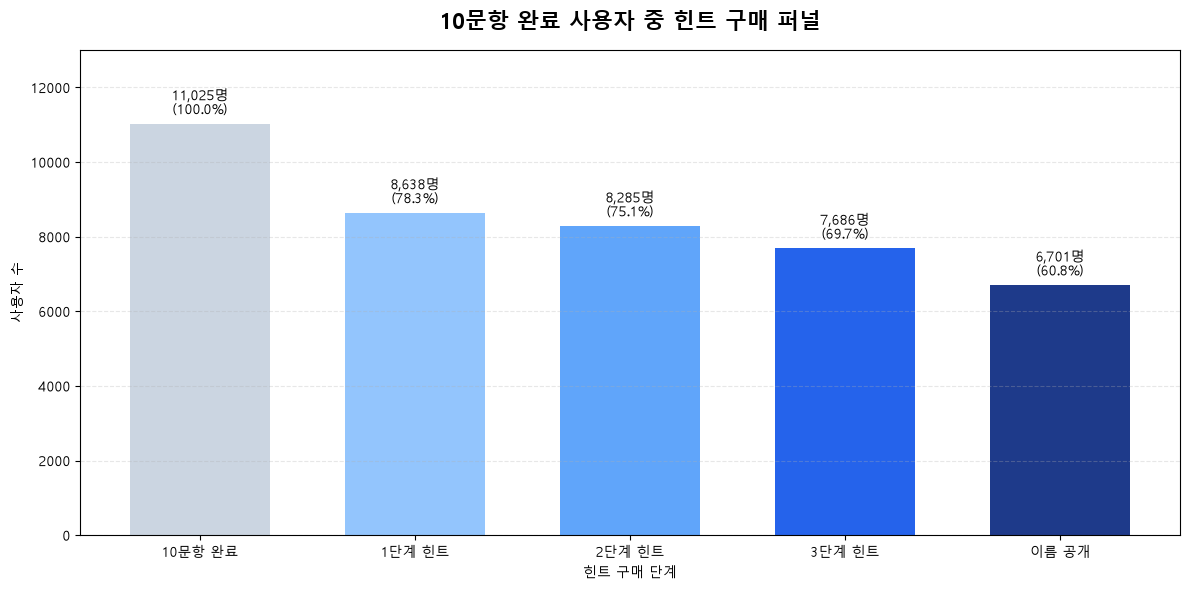

In [38]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

result = df_hint_funnel.iloc[0]

labels = [
    "10문항 완료",
    "1단계 힌트",
    "2단계 힌트",
    "3단계 힌트",
    "이름 공개"
]

values = [
    result["completed_cycle_user_count"],
    result["hint_step1_user_count"],
    result["hint_step2_user_count"],
    result["hint_step3_user_count"],
    result["full_name_user_count"]
]

base_count = values[0]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    labels,
    values,
    color=[
        "#CBD5E1",
        "#93C5FD",
        "#60A5FA",
        "#2563EB",
        "#1E3A8A"
    ],
    width=0.65
)

bar_labels = [
    f"{value:,.0f}명\n"
    f"({value / base_count * 100:.1f}%)"
    for value in values
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=10
)

ax.set_title(
    "10문항 완료 사용자 중 힌트 구매 퍼널",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("힌트 구매 단계")
ax.set_ylabel("사용자 수")
ax.set_ylim(0, max(values) * 1.18)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
import platform
import pandas as pd
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

# --------------------------------------------------
# 퍼널 데이터
# --------------------------------------------------

stages = [
    "가입 완료",
    "친구 5명 확보",
    "투표 시작",
    "투표 세션 완료",
    "1단계 힌트 구매",
    "2단계 힌트 구매",
    "3단계 힌트 구매",
    "이름 공개 구매"
]

user_counts = [
    18001,
    16673,
    14889,
    11025,
    8638,
    8285,
    7686,
    6701
]

funnel_df = pd.DataFrame({
    "stage": stages,
    "user_count": user_counts
})

# 직전 단계 대비 전환율
funnel_df["step_conversion_rate"] = (
    funnel_df["user_count"]
    / funnel_df["user_count"].shift(1)
    * 100
)

funnel_df.loc[0, "step_conversion_rate"] = 100

# 최초 가입자 대비 전환율
funnel_df["overall_conversion_rate"] = (
    funnel_df["user_count"]
    / funnel_df.loc[0, "user_count"]
    * 100
)

# 직전 단계 대비 이탈자 수
funnel_df["drop_count"] = (
    funnel_df["user_count"].shift(1)
    - funnel_df["user_count"]
)

funnel_df.loc[0, "drop_count"] = 0

funnel_df

,stage,user_count,step_conversion_rate,overall_conversion_rate,drop_count
0,가입 완료,18001,100.000000,100.000000,0.0
1,친구 5명 확보,16673,92.622632,92.622632,1328.0
2,투표 시작,14889,89.300066,82.712072,1784.0
3,투표 세션 완료,11025,74.047955,61.246597,3864.0
4,1단계 힌트 구매,8638,78.349206,47.986223,2387.0
5,2단계 힌트 구매,8285,95.913406,46.025221,353.0
6,3단계 힌트 구매,7686,92.770066,42.697628,599.0
7,이름 공개 구매,6701,87.184491,37.225710,985.0


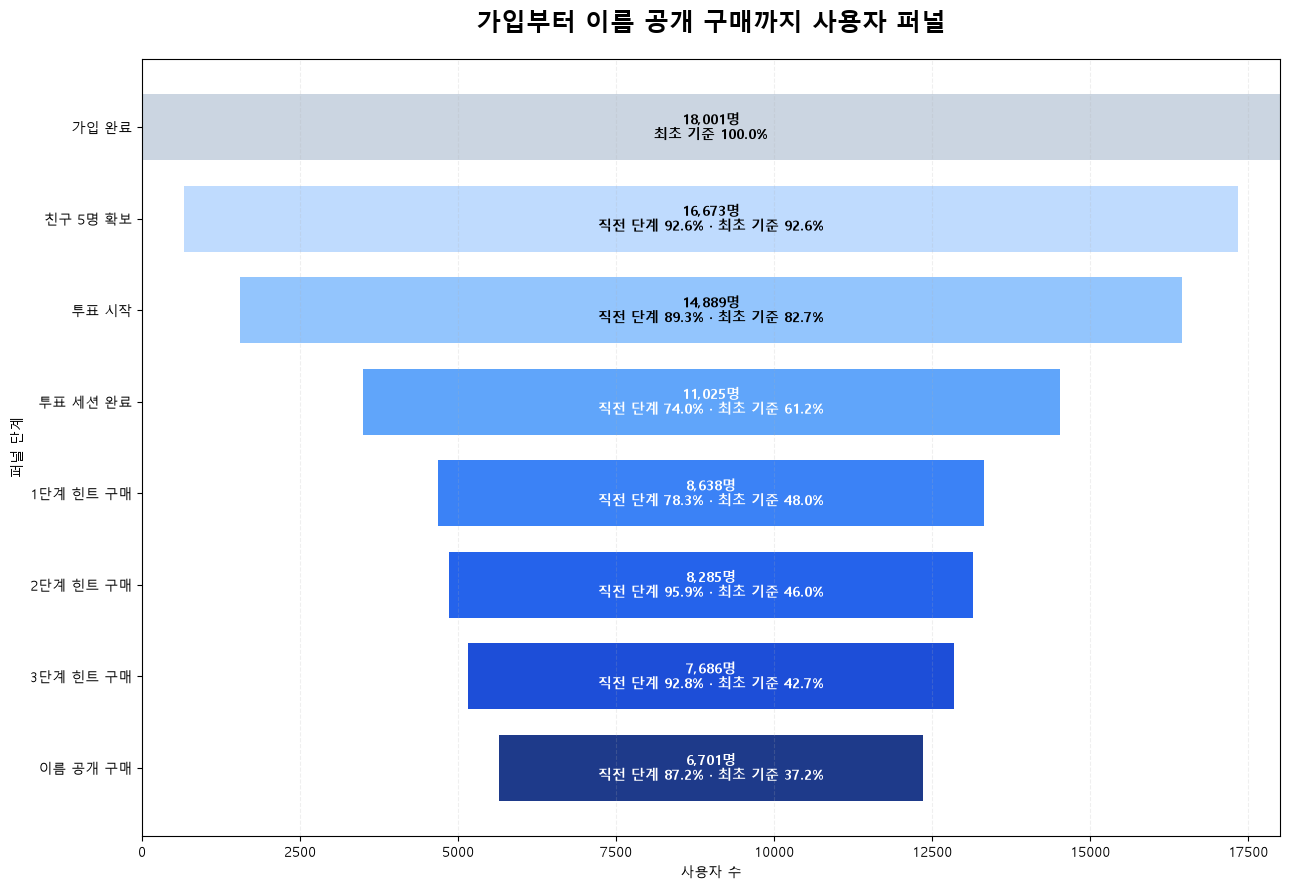

In [40]:
max_count = funnel_df["user_count"].max()

# 막대를 가운데 정렬하기 위한 시작 위치
left_positions = (
    max_count - funnel_df["user_count"]
) / 2

colors = [
    "#CBD5E1",
    "#BFDBFE",
    "#93C5FD",
    "#60A5FA",
    "#3B82F6",
    "#2563EB",
    "#1D4ED8",
    "#1E3A8A"
]

fig, ax = plt.subplots(figsize=(13, 9))

bars = ax.barh(
    funnel_df["stage"],
    funnel_df["user_count"],
    left=left_positions,
    color=colors,
    height=0.72
)

# 가입부터 이름 공개 순서로 위에서 아래로 표시
ax.invert_yaxis()

# 막대 안에 사용자 수와 전환율 표시
for index, bar in enumerate(bars):
    count = funnel_df.loc[index, "user_count"]
    step_rate = funnel_df.loc[
        index,
        "step_conversion_rate"
    ]
    overall_rate = funnel_df.loc[
        index,
        "overall_conversion_rate"
    ]

    center_x = max_count / 2
    center_y = bar.get_y() + bar.get_height() / 2

    # 밝은 막대에는 검은색, 진한 막대에는 흰색
    text_color = "black" if index <= 2 else "white"

    if index == 0:
        label = (
            f"{count:,}명\n"
            f"최초 기준 {overall_rate:.1f}%"
        )
    else:
        label = (
            f"{count:,}명\n"
            f"직전 단계 {step_rate:.1f}% · "
            f"최초 기준 {overall_rate:.1f}%"
        )

    ax.text(
        center_x,
        center_y,
        label,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=text_color
    )

ax.set_title(
    "가입부터 이름 공개 구매까지 사용자 퍼널",
    fontsize=18,
    fontweight="bold",
    pad=20
)
ax.set_xlabel("사용자 수")
ax.set_ylabel("퍼널 단계")

ax.set_xlim(0, max_count)
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

plt.tight_layout()
plt.show()

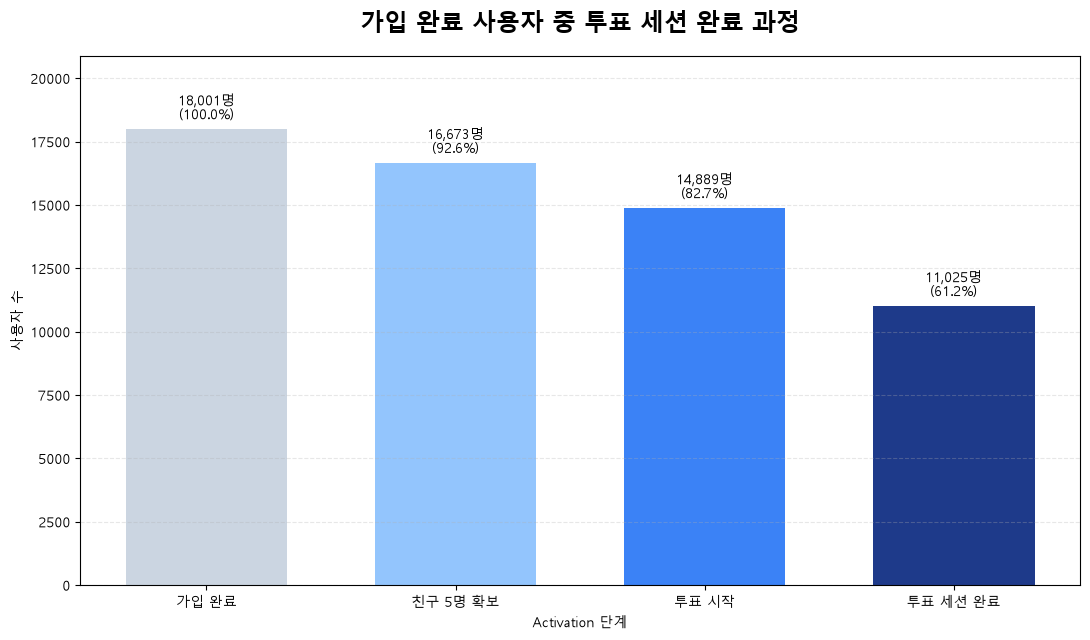

In [42]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

# --------------------------------------------------
# 데이터
# --------------------------------------------------

labels = [
    "가입 완료",
    "친구 5명 확보",
    "투표 시작",
    "투표 세션 완료"
]

values = [
    18001,
    16673,
    14889,
    11025
]

base_count = values[0]

# 가입 완료 대비 도달률
overall_rates = [
    value / base_count * 100
    for value in values
]

colors = [
    "#CBD5E1",
    "#93C5FD",
    "#3B82F6",
    "#1E3A8A"
]

# --------------------------------------------------
# 막대그래프
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6.5))

bars = ax.bar(
    labels,
    values,
    color=colors,
    width=0.65
)

# 막대 위에 사용자 수와 비율 표시
bar_labels = [
    f"{value:,}명\n({rate:.1f}%)"
    for value, rate in zip(
        values,
        overall_rates
    )
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=5,
    fontsize=10
)

ax.set_title(
    "가입 완료 사용자 중 투표 세션 완료 과정",
    fontsize=17,
    fontweight="bold",
    pad=18
)
ax.set_xlabel("Activation 단계")
ax.set_ylabel("사용자 수")

ax.set_ylim(
    0,
    max(values) * 1.16
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()